# BiomedCLIP: Multimodal Learning in Biomedical Imaging

> This notebook is based on the tutorial **"CLIP It Right: Connecting Medical Images with Meaning"** by Sarah KM, published on [Medium](https://medium.com/@skm.sarah.kaye2/clip-it-right-connecting-medical-images-with-meaning-c0ca52fe962b). All credit for the original tutorial goes to the author and the Institute for Artificial Intelligence in Cardiovascular Medicine at Heidelberg University Hospital.

# 1. Introduction

In medicine, a good diagnosis rarely comes from a single data source. A radiologist reads an image alongside a clinical note. A cardiologist combines an ECG with lab results and imaging. This layered reasoning across different types of data is called **multimodal reasoning**, and teaching AI to do the same is one of the most active areas of research today.

**Multimodal AI** learns to work with different data types together, text and images, by mapping them into a shared representation space where they can be directly compared.

In this notebook, we work with [BiomedCLIP](https://arxiv.org/abs/2303.00915), a model trained on 15 million biomedical image-text pairs from PubMed Central. It connects medical images with their clinical descriptions using **contrastive learning**, a training strategy that pulls matching pairs close together in embedding space while pushing unrelated ones apart.

We will go through the full pipeline step by step:
- How text is tokenized and encoded
- How images are processed by a Vision Transformer
- How both modalities are aligned in a shared space
- How this enables zero-shot classification without any labeled training data

---

## The Core Idea

The challenge is that text and images are completely different formats. You cannot directly compare a sentence to a grid of pixels. The solution is to encode both into vectors of the same dimension, then train the model so that related pairs are geometrically close.

> A chest X-ray showing cardiomegaly and the sentence "X-ray of a patient with Cardiomegaly" end up near each other in this space. Unrelated pairs end up far apart.

Once this space is learned, it unlocks a lot of powerful capabilities: image retrieval, report matching, and classification without retraining.

# 2. Setup

We need three libraries:

- **`open_clip_torch`**: loads pretrained CLIP-style models including both encoders
- **`transformers`**: provides the PubMedBERT tokenizer for text processing
- **`ipywidgets`**: adds interactive widgets (dropdowns, buttons) to the notebook

In [ ]:
# Install required libraries
!pip install -q open_clip_torch==2.23.0 transformers==4.41.0
%pip install -q ipywidgets

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.8/43.8 kB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 35.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 83.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 20.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 63.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 25.2 MB/s eta 0:00:00


In [ ]:
# Core Python utilities
import os
import numpy as np
import pandas as pd
import torch

# Image handling & visualization
from PIL import Image
import matplotlib.pyplot as plt
from urllib.request import urlopen

# Multimodal model (CLIP)
from open_clip import create_model_from_pretrained, get_tokenizer

# Interactive notebook tools
# Used for sliders, dropdowns, and interactive exploration in Jupyter
from ipywidgets import interact, interactive, fixed, interact_manual
import ipywidgets as widgets

/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


# 3. Loading BiomedCLIP

We load the pretrained BiomedCLIP model, which comes with two encoders already aligned:

- a **Vision Transformer (ViT-B/16)** for images
- **PubMedBERT** for text

We also move the model to GPU if available, set it to evaluation mode since we are not training, and load the tokenizer separately.

In [ ]:
# Load the pretrained BiomedCLIP model and its preprocessing function
model, preprocess = create_model_from_pretrained(
    'hf-hub:microsoft/BiomedCLIP-PubMedBERT_256-vit_base_patch16_224'
)

# Select device (GPU if available, otherwise CPU)
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

# Move model to the selected device
model.to(device)

# Set model to evaluation mode (disables training-specific behavior)
model.eval()

# Load tokenizer for text processing
tokenizer = get_tokenizer(
    'hf-hub:microsoft/BiomedCLIP-PubMedBERT_256-vit_base_patch16_224'
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


open_clip_pytorch_model.bin:   0%|          | 0.00/784M [00:00<?, ?B/s]

open_clip_config.json:   0%|          | 0.00/707 [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/28.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

# 4. Text Embedding

Before the model can process text, it needs to convert words into numbers. This happens in several steps.

**Step 1: Tokenization.** The sentence is split into small units called tokens. BiomedCLIP uses PubMedBERT's tokenizer, which breaks rare or compound medical terms into subwords:
```
"cardiomegaly" -> ["cardio", "##megaly"]
```
This lets the model handle medical vocabulary it may not have seen as a whole word.

**Step 2: Vocabulary mapping.** Each token gets an integer ID from a fixed vocabulary.

**Step 3: Static embedding lookup.** Each ID maps to a learned vector. At this point, representations are context-free: the same word always gives the same vector.

**Step 4: Transformer encoding.** PubMedBERT processes the full token sequence using self-attention, letting each token update its representation based on all others. This is where context kicks in: "mass" in "lung mass" gets a different vector than "mass" in "atomic mass".

**Step 5: Aggregation.** The token-level vectors are pooled into a single fixed-size vector (512 dimensions) representing the whole sentence. This is the **text embedding**.

In the next cells, we explore this process interactively.

In [ ]:
def tokenize_text(text, max_context_length=256):
  """
  Convert a text into tokens and token IDs ready for the model.
  Args:
    text (str): The input sentence.
    max_context_length (int): Max number of tokens the model can handle.
      Short texts are padded, long texts are cut.

  Returns:
    token_ids: Tensor of token IDs (fixed length).
    tokens: List of readable tokens.
    token_nos: Number of real (non-padding) tokens.
    nonzero_mask: Mask showing which tokens are real vs padding.
  """
  if not text.strip():
    print("Input is empty. Please provide a valid sentence.")
    return

  if len(text) > 512:
    print("Text too long (max 512 characters). Please shorten it.")
    return

  # Convert text into token IDs (model input format)
  token_ids = tokenizer([text], context_length=max_context_length).to(device)
  # Convert token IDs back to readable tokens (for debugging/interpretation)
  readable_tokens = tokenizer.tokenizer.convert_ids_to_tokens(
    token_ids[0].tolist()
  )
  # Remove padding tokens
  token_ids_flat = token_ids.squeeze(0)  # shape: [context_length]
  # Mask: True for real tokens, False for padding
  valid_tokens_mask = token_ids_flat != 0
  # Count number of valid tokens
  num_valid_tokens = valid_tokens_mask.sum()

  return token_ids, readable_tokens, num_valid_tokens, valid_tokens_mask

In [ ]:
@interact_manual(text='CT scan reveals a mass in the right lung apex')
def tokenize_text_interactive(text):
  """
  Interactive tool to visualize how a sentence is tokenized.

  It shows:
  - the original text
  - the tokens produced by the tokenizer
  - their corresponding token IDs
  """
  # Tokenize input sentence
  token_ids, tokens, num_valid_tokens, _ = tokenize_text(text)
  # Print the text with "Text:" underlined for better visual readability
  print(f"\n\033[4mText:\033[0m\n{text}")
  # Build readable table (only valid tokens, no padding)
  df = pd.DataFrame({
    "Token": tokens[:num_valid_tokens],
    "Token ID": token_ids[0][:num_valid_tokens].tolist()
  })
  # Display table in notebook
  display(df)

interactive(children=(Text(value='CT scan reveals a mass in the right lung apex', description='text'), Button(…

**Understanding the Tokenizer Output**

The table shows how the sentence was broken down before entering the model. A few tokens are worth noting:

- **`[CLS]`**: a special token placed at the start. After all Transformer layers, its hidden state is used as the global sentence representation.
- **`[SEP]`**: marks the end of the sentence.
- **`[PAD]`**: fills empty positions so all sequences in a batch have the same length.

Content words sometimes get split into fragments. For example, `##nia` means "continuation of the previous token." This is WordPiece tokenization, and it is what allows the model to handle medical terminology without needing a separate vocabulary entry for every possible term.

Now that we can see how individual tokens are represented, the next step is to look at how they relate to each other before the Transformer processes them.

In [ ]:
@interact_manual(text='CT scan reveals a mass in the right lung apex')
def visualize_token_embedding_correlation(text):
  """
  Visualize correlation between token embeddings of a given sentence.

  This function:
  - tokenizes the input text
  - extracts token embeddings from the model
  - computes pairwise correlation between token embeddings
  - visualizes the correlation matrix as a heatmap
  """
  # tokenization
  token_ids, token_strings, num_valid_tokens, valid_token_mask = tokenize_text(text)
  # Extract token embeddings (pre-transformer layer)
  # Shape: [1, context_length, embedding_dim]
  with torch.no_grad():  # run model in read-only mode
    token_embeddings = model.text.transformer.embeddings.word_embeddings(
        token_ids
    )
  # Remove batch dimension → [context_length, embedding_dim]
  token_embeddings = token_embeddings.squeeze(0)
  valid_embeddings = token_embeddings[valid_token_mask]
  valid_tokens = [token_strings[i]
                  for i, is_valid in enumerate(valid_token_mask)
                  if is_valid
                ]
  # Convert to NumPy for correlation computation
  embeddings_array = valid_embeddings.cpu().numpy()
  # Compute correlation matrix
  correlation_matrix = np.corrcoef(embeddings_array)
  # Remove self-correlation for better visualization
  np.fill_diagonal(correlation_matrix, 0)

  # Visualization
  plt.figure(figsize=(8, 6))
  plt.imshow(correlation_matrix, cmap="coolwarm", vmin=-1, vmax=1)
  plt.colorbar(label="Correlation")

  plt.title("Token Embedding Correlation Matrix")

  # Set axis labels using tokens
  plt.xticks(
      ticks=np.arange(len(valid_tokens)),
      labels=valid_tokens,
      rotation=90,
      fontsize=8
  )
  plt.yticks(
      ticks=np.arange(len(valid_tokens)),
      labels=valid_tokens,
      fontsize=8
  )

  plt.show()

interactive(children=(Text(value='CT scan reveals a mass in the right lung apex', description='text'), Button(…

**Static vs. Contextual Embeddings**

This heatmap shows similarity between token vectors **before** the Transformer. At this stage, the representations are purely based on co-occurrence patterns learned during pretraining.

Function words like "the", "a", and "in" cluster together because they appear in similar contexts across all sentences. Content words like "lung" are more isolated.

This tells us something important: the raw embeddings are not yet semantic. The Transformer's self-attention is what turns them into meaningful, context-aware representations. BiomedCLIP aligns images to post-Transformer embeddings, not these static ones.

Next, we move up to the sentence level and see what the full text embeddings look like.

Input Texts:

1. X-ray of a patient with Cardiomegaly
2. MRI of a patient having myocardial scar
3. My daughter likes bert
4. Marvin thinks that Southside festival was fun
5. Im going to be king of the pirates, says Monkey D. Luffy
[[0.         0.77696184 0.48103462 0.46352433 0.44608893]
 [0.77696184 0.         0.37620391 0.4552513  0.46850402]
 [0.48103462 0.37620391 0.         0.59066831 0.39130385]
 [0.46352433 0.4552513  0.59066831 0.         0.52440211]
 [0.44608893 0.46850402 0.39130385 0.52440211 0.        ]]


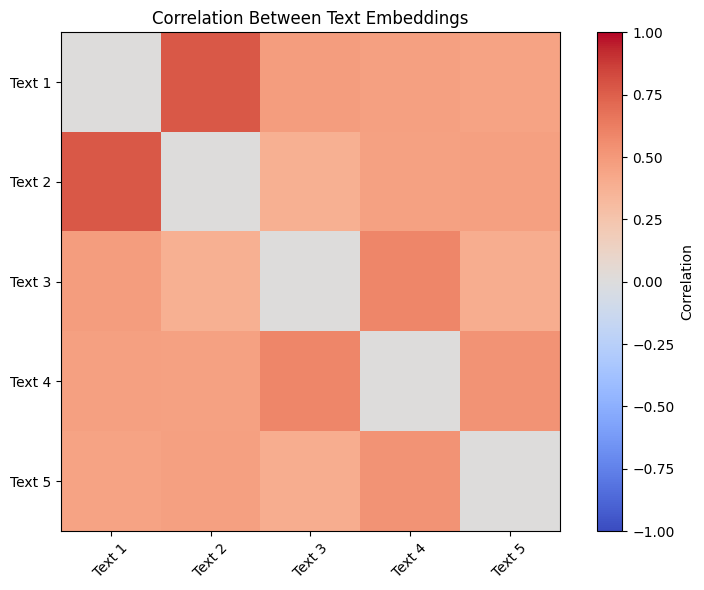

In [ ]:
def compute_text_embedding_correlation(texts):
  """
  Compute and visualize correlation between text embeddings.
  Args:
    texts : list of str
  """
  context_length = 256
  tokenized_inputs = tokenizer(texts, context_length=context_length).to(device)
  # Text encoding (no gradients)
  with torch.no_grad():
    embeddings = model.encode_text(tokenized_inputs)

  embeddings_np = embeddings.cpu().numpy()
  # Correlation matrix
  corr_matrix = np.corrcoef(embeddings_np)
  # Remove self-correlation for visualization clarity
  np.fill_diagonal(corr_matrix, 0)

  # Labels
  num_texts = len(texts)
  labels = [f"Text {i+1}" for i in range(num_texts)]
  print("Input Texts:\n")
  for i, text in enumerate(texts, 1):
    print(f"{i}. {text}")
  print(corr_matrix)

  # Plot heatmap
  plt.figure(figsize=(8, 6))
  im = plt.imshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)
  plt.colorbar(im, label="Correlation")

  plt.xticks(np.arange(num_texts), labels, rotation=45)
  plt.yticks(np.arange(num_texts), labels)

  plt.title("Correlation Between Text Embeddings")
  plt.tight_layout()
  plt.show()

texts=[
  'X-ray of a patient with Cardiomegaly',
  'MRI of a patient having myocardial scar',
  'My daughter likes bert',
  'Marvin thinks that Southside festival was fun',
  'Im going to be king of the pirates, says Monkey D. Luffy',
]
compute_text_embedding_correlation(texts=texts)

**Sentence-Level Similarity**

Here the comparison is between complete sentence embeddings. The pattern is much clearer: the two medical imaging sentences (Text 1 and Text 2) are strongly correlated, even though they describe different conditions and different modalities (X-ray vs. MRI).

BiomedCLIP groups them by domain, not just by shared words. The remaining informal sentences form a looser cluster driven more by sentence structure than shared meaning.

This domain awareness is a direct result of training on biomedical literature. It is exactly the property we need for tasks like clinical report retrieval.

With text covered, we now turn to the image side of the pipeline.

# 5. Image Embedding

The goal is the same as with text: convert the raw input into a fixed-size vector that captures its meaning. But images require a different architecture.

**From pixels to patches.** BiomedCLIP uses a Vision Transformer (ViT-B/16). Instead of scanning the image with convolutional filters, ViT divides it into 16x16 pixel patches, flattens each patch into a vector, and processes them as a sequence. For a 224x224 image, that gives 196 patches.

**Positional encoding.** Transformers do not inherently know the order of their inputs. A learned positional encoding is added to each patch vector so the model knows where each patch sits in the image.

**Self-attention across patches.** The patch sequence goes through Transformer layers, where each patch can attend to all others. This allows the model to capture both local details and global structure.

**The image embedding.** A `[CLS]` token is prepended to the sequence. Its final hidden state is the **image embedding**: a single vector summarizing the entire image.

**Why not CNNs?** CNNs are strong at detecting local features (edges, textures) but limited at capturing relationships between distant regions. ViT handles this naturally through attention. In medical imaging, where global context matters a lot (the position of an abnormality relative to surrounding anatomy), this is a meaningful advantage.

In the cells below, we load a mixed set of medical and natural images and look at how their embeddings cluster.

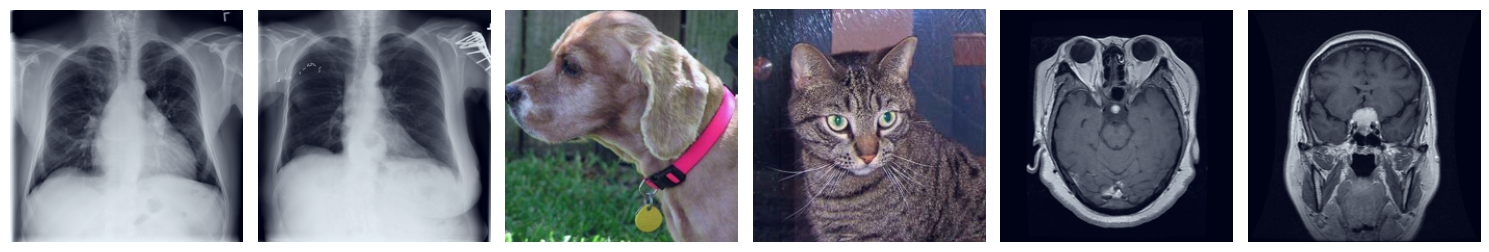

In [ ]:
# These images include natural images (cat, dog) and medical images (brain MRI)
image_urls =[
    'https://drive.google.com/uc?export=download&id=1PdVZx-NfT4_4oIBbvp3Q_xSn3oIeXvdR',
    'https://drive.google.com/uc?export=download&id=1SdWFcamFMhQLCSiseDvD0HNvvc9fu0Fd',
    'https://drive.google.com/uc?export=download&id=1y014y_cHZATAxOLmfGk04cXTs6UQU0TX', # cat image
    'https://drive.google.com/uc?export=download&id=14oQfidkXVVaIc1xr1jqpXfgyILmseQpH', # dog image
    'https://drive.google.com/uc?export=download&id=1SaKcCjyey81JF2PgSX5AW2PRzFbRfckD', # brain MRI 1
    'https://drive.google.com/uc?export=download&id=1rxjn4hFZYGcUZ5-tpgaxRKC8I1667pRf'] # brain MRI 2

# Each image is opened from URL, preprocessed, and stacked into a batch tensor
images = torch.stack([
    preprocess(Image.open(urlopen(url)))
    for url in image_urls
]).to(device)

# Convert tensors to displayable format and plot them side by side
num_images = len(images)
fig, axes = plt.subplots(1, num_images, figsize=(15, 5))
for i, ax in enumerate(axes):
    # Convert from (C, H, W) → (H, W, C) for matplotlib
    img = images[i].cpu().permute(1, 2, 0)

    # Normalize for proper visualization
    img = (img - img.min()) / (img.max() - img.min())

    ax.imshow(img)
    ax.axis('off')  # hide axis for cleaner visualization

plt.tight_layout()
plt.show()

In [ ]:
@interact_manual(
  Image_CXR1=True,
  Image_CXR2=True,
  Image_dog=True,
  Image_cat=True,
  Image_brainMRI1=False,
  Image_brainMRI2=False
)
def compute_image_embedding_correlation(
  Image_CXR1, Image_CXR2, Image_dog, Image_cat, Image_brainMRI1, Image_brainMRI2
):
  """
  Compute and visualize correlation between image embeddings.

  The user selects which images to include, then:
  1. Selected images are loaded from URLs
  2. Encoded using a pretrained vision model
  3. Pairwise correlation between embeddings is computed
  4. Results are displayed as a heatmap
  """
  # Build selection mask and filter selected images
  selected_flags = [
    Image_CXR1,
    Image_CXR2,
    Image_dog,
    Image_cat,
    Image_brainMRI1,
    Image_brainMRI2,
  ]
  selected_image_urls = [
    url for idx, url in enumerate(image_urls)
    if selected_flags[idx]
  ]
  print("Selected images:\n")
  for i, url in enumerate(selected_image_urls, 1):
    print(f"{i}. {url}")

  # Load and preprocess images
  images = torch.stack([
    preprocess(Image.open(urlopen(url)))
    for url in selected_image_urls
  ]).to(device)

  # Encode images into embeddings
  with torch.no_grad():
    image_embeddings = model.encode_image(images)
  embeddings_np = image_embeddings.cpu().numpy()

  # Compute correlation matrix & remove self-correlation
  corr_matrix = np.corrcoef(embeddings_np)
  np.fill_diagonal(corr_matrix, 0)
  print(corr_matrix)
  # Visualization
  num_images = len(selected_image_urls)
  labels = [f"Image {i+1}" for i in range(num_images)]

  plt.figure(figsize=(8, 6))
  heatmap = plt.imshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)
  plt.colorbar(heatmap, label="Correlation")

  plt.xticks(np.arange(num_images), labels, rotation=45)
  plt.yticks(np.arange(num_images), labels)

  plt.title("Correlation Between Image Embeddings")
  plt.tight_layout()
  plt.show()

interactive(children=(Checkbox(value=True, description='Image_CXR1'), Checkbox(value=True, description='Image_…

**Image Embedding Clusters**

The heatmap shows two clear clusters. The two chest X-rays are strongly correlated with each other, and the cat and dog images form their own separate cluster. The two groups are well separated.

This makes sense: BiomedCLIP was trained on biomedical image-text pairs, so it has learned a representation space where medical images occupy a distinct region. Even without any labels, the model separates radiology images from natural photographs purely based on learned visual features.

This domain separation is what makes the next step possible: aligning image embeddings with clinical text descriptions.

# 6. Cross-Modal Alignment

So far text and image embeddings have been explored separately. Now we bring them together.

BiomedCLIP trains both encoders jointly so their outputs live in the same vector space. A matching image-text pair should be close together. A non-matching pair should be far apart. This is the contrastive learning objective.

**Prompt templates matter.** CLIP models were trained on full sentences, not isolated labels. Feeding "cardiomegaly" alone is suboptimal. A template like:

```
"This is an image of X-ray of a patient with Cardiomegaly"
```

much better matches the style of the training data and improves alignment quality.

In the cells below, we tokenize a set of clinical labels using this template, load matching chest X-rays, and compute the image-text correlation matrix.

In [ ]:
def tokenize_text_list(
    text_list,
    context_length: int = 256,
    show_tokens: bool = True,
    prefix: str = "This is an image of "
):
  """
  Tokenize a list of texts using a pretrained tokenizer and optionally display tokens.
  Each text is first prefixed with a template string, then converted into token IDs.
  """
  # Add prompt prefix and tokenize
  prompted_texts = [prefix + text for text in text_list]
  tokenized_batch = tokenizer(
    prompted_texts,
    context_length=context_length
  ).to(device)
  # Move to CPU for inspection/printing
  input_ids_cpu = tokenized_batch.cpu()

  # debug: display tokens
  if show_tokens:
    for i, input_ids in enumerate(input_ids_cpu):
      # Remove batch dimension if present
      token_ids = input_ids.squeeze(0)
      # Identify non-padding tokens (assumes padding = 0)
      valid_mask = token_ids != 0
      valid_length = valid_mask.sum().item()
      # Convert token IDs back to readable tokens
      tokens = tokenizer.tokenizer.convert_ids_to_tokens(
        token_ids.tolist()
      )
      print(f"\nSequence {i + 1}")
      print(f"Text: {prompted_texts[i]}")
      print(f"Token IDs: {token_ids.tolist()[:valid_length]}")
      print(f"Tokens:    {tokens[:valid_length]}")

  return tokenized_batch, input_ids_cpu
# Example usage
cxr_labels = [
    "X-ray of a patient with Cardiomegaly",
    "X-ray of a patient with Hernia",
    "X-ray of a patient with Mass",
    "X-ray of a patient with Nodule",
    "X-ray of a patient with Pneumothorax",
    "X-ray of a patient with No Finding",
    "X-ray of a patient with Emphysema",
    "X-ray of a patient with pulmonary metastases"
]

tokenized_texts, input_ids = tokenize_text_list(cxr_labels)


Sequence 1
Text: This is an image of X-ray of a patient with Cardiomegaly
Token IDs: [2, 1805, 1744, 1683, 4831, 1685, 65, 16, 4895, 1685, 42, 2348, 1715, 22339, 3947, 7322, 1005, 3]
Tokens:    ['[CLS]', 'this', 'is', 'an', 'image', 'of', 'x', '-', 'ray', 'of', 'a', 'patient', 'with', 'cardio', '##me', '##gal', '##y', '[SEP]']

Sequence 2
Text: This is an image of X-ray of a patient with Hernia
Token IDs: [2, 1805, 1744, 1683, 4831, 1685, 65, 16, 4895, 1685, 42, 2348, 1715, 11823, 3]
Tokens:    ['[CLS]', 'this', 'is', 'an', 'image', 'of', 'x', '-', 'ray', 'of', 'a', 'patient', 'with', 'hernia', '[SEP]']

Sequence 3
Text: This is an image of X-ray of a patient with Mass
Token IDs: [2, 1805, 1744, 1683, 4831, 1685, 65, 16, 4895, 1685, 42, 2348, 1715, 2962, 3]
Tokens:    ['[CLS]', 'this', 'is', 'an', 'image', 'of', 'x', '-', 'ray', 'of', 'a', 'patient', 'with', 'mass', '[SEP]']

Sequence 4
Text: This is an image of X-ray of a patient with Nodule
Token IDs: [2, 1805, 1744, 1683, 4831, 168

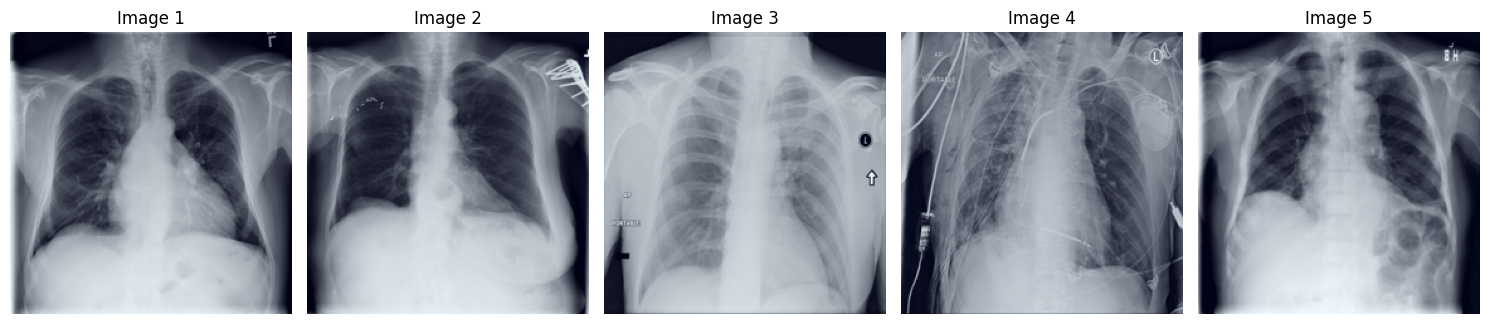

Text 1: X-ray of a patient with Cardiomegaly
Text 2: X-ray of a patient with Hernia
Text 3: X-ray of a patient with Mass
Text 4: X-ray of a patient with Nodule
Text 5: X-ray of a patient with Pneumothorax
Text 6: X-ray of a patient with No Finding
Text 7: X-ray of a patient with Emphysema
Text 8: X-ray of a patient with pulmonary metastases


In [ ]:
# Each image corresponds to a specific chest X-ray condition or normal case
test_image_urls = [
  'https://drive.google.com/uc?export=download&id=1PdVZx-NfT4_4oIBbvp3Q_xSn3oIeXvdR',  # Cardiomegaly
  'https://drive.google.com/uc?export=download&id=1SdWFcamFMhQLCSiseDvD0HNvvc9fu0Fd',  # Hernia
  'https://drive.google.com/uc?export=download&id=13tcyHIUX-Qz1-_NE4sbX3kXUE_p2IgUg',  # Mass | Nodule
  'https://drive.google.com/uc?export=download&id=1DVRoHw4QMQOsTSs_b2w4eabdYkTP2vJb',  # Emphysema | Pneumothorax
  'https://drive.google.com/uc?export=download&id=1zV8TLxvFIGcCq8wFjgs2iyPJDPvM-osk'   # Healthy patient
]
# Convert images into tensors and stack them into a batch
image_batch = torch.stack([
  preprocess(Image.open(urlopen(url)))
  for url in test_image_urls
]).to(device)

# Visualize images
num_images = len(image_batch)
fig, axes = plt.subplots(1, num_images, figsize=(15, 5))
for i, ax in enumerate(axes):
  # Convert from (C, H, W) → (H, W, C) for visualization
  img = image_batch[i].cpu().permute(1, 2, 0)

  # Normalize for display stability
  img = (img - img.min()) / (img.max() - img.min())

  ax.imshow(img)
  ax.axis("off")
  ax.set_title(f"Image {i + 1}")

plt.tight_layout()
plt.show()

# Displays the diagnostic label associated with each image
for idx, label in enumerate(cxr_labels):
  print(f"Text {idx + 1}: {label}")

Texts:
T1: This is an image of X-ray of a patient with Cardiomegaly
T2: This is an image of X-ray of a patient with Hernia
T3: This is an image of X-ray of a patient with Mass
T4: This is an image of X-ray of a patient with Nodule
T5: This is an image of X-ray of a patient with Pneumothorax
T6: This is an image of X-ray of a patient with No Finding
T7: This is an image of X-ray of a patient with Emphysema
T8: This is an image of X-ray of a patient with pulmonary metastases


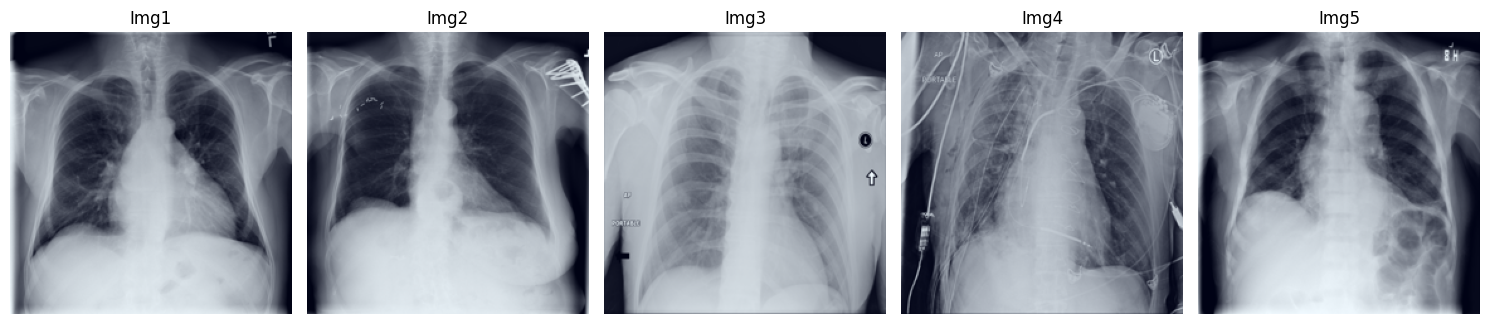

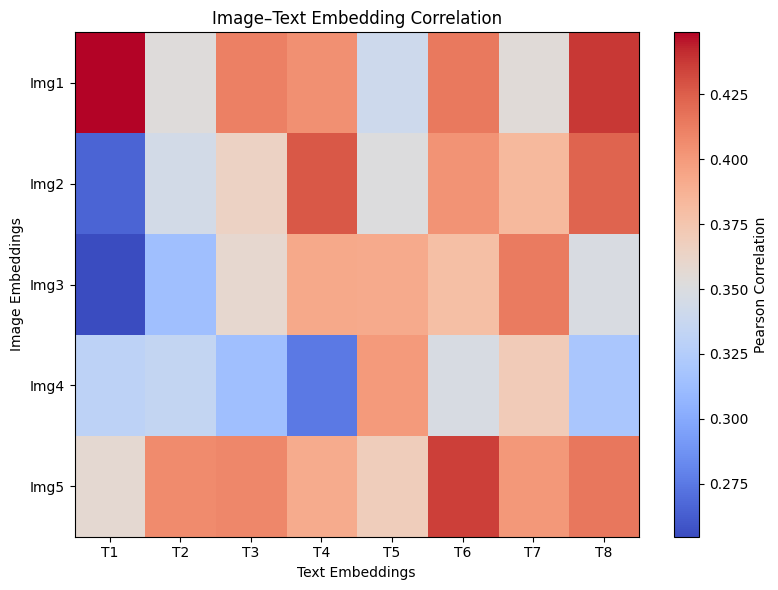

In [ ]:
with torch.no_grad():
  # 1. Encode text and images into embedding vectors
  text_embeddings = model.encode_text(input_ids)
  image_embeddings = model.encode_image(image_batch)

# Convert embeddings to NumPy for analysis
text_embeddings_np = text_embeddings.cpu().numpy()
image_embeddings_np = image_embeddings.cpu().numpy()

# Compute cross-correlation between image and text embeddings
# We concatenate both sets and compute a full correlation matrix
combined = np.vstack([image_embeddings_np, text_embeddings_np])
corr_matrix = np.corrcoef(combined)
# Split matrix into image vs text block
num_images = image_embeddings_np.shape[0]
num_texts = text_embeddings_np.shape[0]
image_text_corr = corr_matrix[:num_images, num_images:]

# Display text prompts
prompt_template = "This is an image of "
print("Texts:")
for i, label in enumerate(cxr_labels, 1):
  print(f"T{i}: {prompt_template + label}")

# Display images
fig, axes = plt.subplots(1, num_images, figsize=(15, 5))
for i, ax in enumerate(axes):
  img = image_batch[i].cpu().permute(1, 2, 0)  # CHW → HWC
  # Normalize for visualization
  img = (img - img.min()) / (img.max() - img.min())

  ax.imshow(img)
  ax.axis("off")
  ax.set_title(f"Img{i+1}")

plt.tight_layout()
plt.show()

text_labels = ["T1", "T2", "T3", "T4", "T5", "T6", "T7", "T8" ]
image_labels = ["Img1", "Img2", "Img3", "Img4", "Img5"]

# Labels for visualization
plt.figure(figsize=(8, 6))
plt.imshow(image_text_corr, cmap="coolwarm", aspect="auto")
plt.colorbar(label="Pearson Correlation")

plt.title("Image–Text Embedding Correlation")
plt.xlabel("Text Embeddings")
plt.ylabel("Image Embeddings")

plt.xticks(np.arange(num_texts), text_labels)
plt.yticks(np.arange(num_images), image_labels)

plt.tight_layout()
plt.show()

**Reading the Cross-Modal Matrix**

Each cell in this matrix shows how similar an image embedding is to a text label embedding in the shared space.

Do not try to interpret the absolute values directly. What matters is the **relative ranking within each row**: for a given image, the correct label should score higher than the others, even if the differences are small. The model was trained to discriminate, not to output calibrated probabilities.

Semantically similar labels (like "Mass" and "Nodule") may score close to each other for the same image because both their visual appearance and textual descriptions overlap. That is a property of the label set, not a model failure.

The matrix is best read as a ranking signal: does the right label come out on top?

This ranking logic is exactly what powers zero-shot classification, which we look at next.

# 7. Zero-Shot Classification

Zero-shot classification means assigning a label to an image the model was never explicitly trained to classify. No task-specific training data, no fine-tuning.

It works through similarity-based ranking in the shared embedding space:

1. Define candidate labels as text prompts
2. Encode them into text embeddings
3. Encode the query image into an image embedding
4. Compute similarity between the image and each label
5. Apply softmax to get a probability distribution
6. Pick the label with the highest score

This is not a special trick added on top of the model. It is a direct consequence of contrastive pretraining: because the model learned to align images and text from the same biomedical domain, classification becomes a nearest-neighbor problem in embedding space.

In medicine, this matters because building a new diagnostic classifier normally requires annotating thousands of images. With zero-shot, you only need to describe the condition in plain language.

In [ ]:
# Zero-shot CLIP prediction via image–text similarity ranking
with torch.no_grad():
  image_embeddings, text_embeddings, logit_scale = model(images, tokenized_texts)

  # Compute similarity scores (logits)
  similarity_logits = (
      logit_scale * image_embeddings @ text_embeddings.T
  )

  # Convert logits into probabilities across text candidates
  probabilities = similarity_logits.softmax(dim=-1)

  # Rank predictions (highest similarity first)
  ranked_indices = torch.argsort(probabilities, dim=-1, descending=True)

  # Move to CPU for analysis/visualization
  probabilities = probabilities.cpu().numpy()
  ranked_indices = ranked_indices.cpu().numpy()

top_k = -1  # use all classes (no truncation)

# Dropdown selector to choose an image
image_selector = widgets.Dropdown(
  options=[(f"Image {i+1}", i) for i in range(len(test_image_urls))],
  description="Select Image:",
)

@interact_manual(idx=image_selector)
def display_image_predictions(idx):
  """
  Display selected image and its top-3 CLIP predictions.
  """
  image = Image.open(urlopen(test_image_urls[idx]))

  plt.imshow(image, cmap="gray")
  plt.axis("off")
  plt.title(f"Image {idx + 1}")
  plt.show()

  print("\nTop Predictions:")

  for rank in range(3):
    label_idx = ranked_indices[idx][rank]
    score = probabilities[idx][label_idx] * 100

    # Highlight best prediction
    if rank == 0:
        print(f"\033[1m{cxr_labels[label_idx]}: {score:.1f}\033[0m")
    else:
        print(f"{cxr_labels[label_idx]}: {score:.1f}")

interactive(children=(Dropdown(description='Select Image:', options=(('Image 1', 0), ('Image 2', 1), ('Image 3…

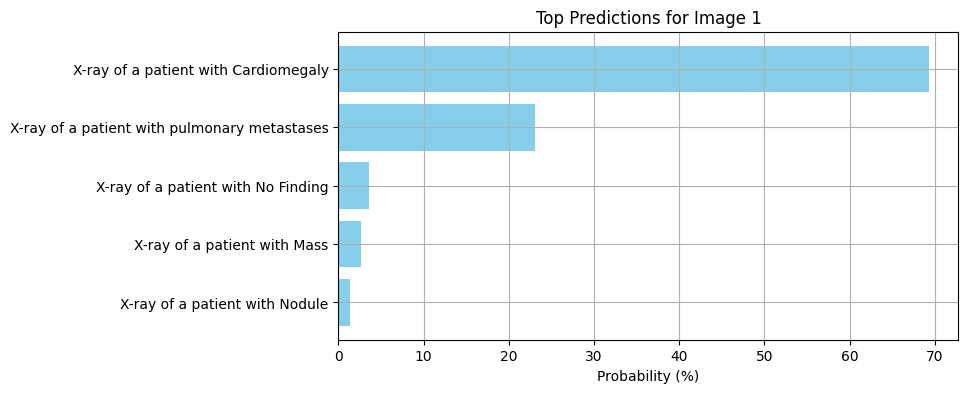

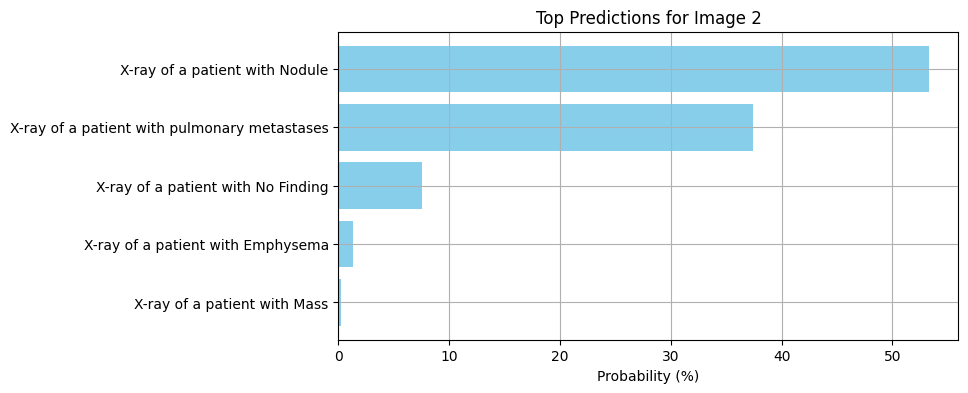

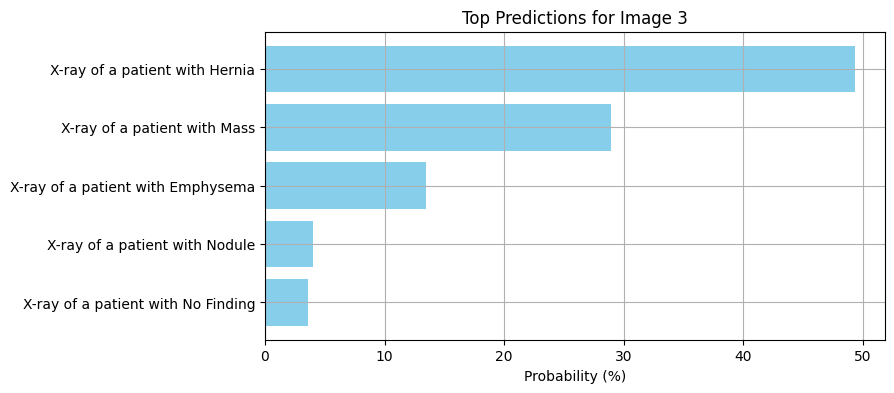

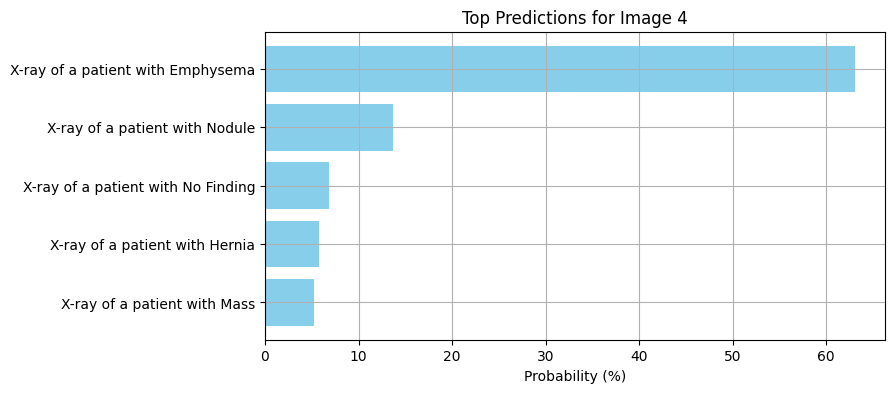

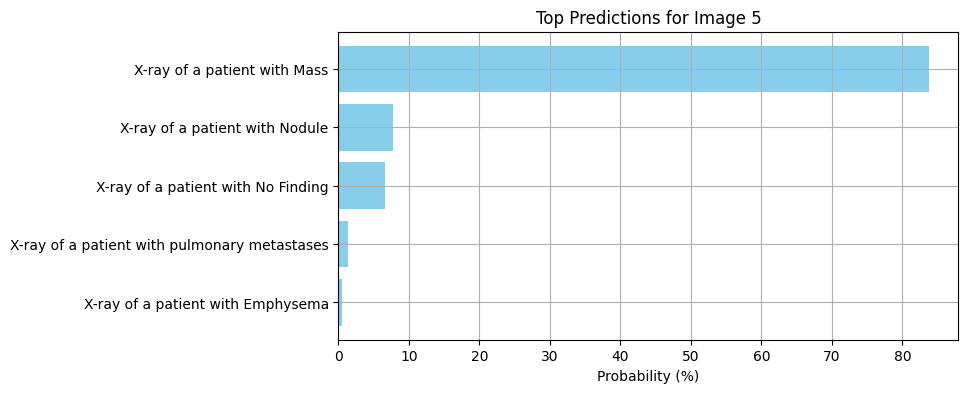

In [ ]:
def plot_top_predictions_per_image(image_index):
  """
  Plot the top-5 predicted text labels for a given image
  based on CLIP similarity probabilities.
  """
  image_probs = probabilities[image_index]
  top_indices = ranked_indices[image_index][:5]
  top_labels = [cxr_labels[i] for i in top_indices]
  top_values = [image_probs[i] for i in top_indices]

  plt.figure(figsize=(8, 4))
  bars = plt.barh(top_labels[::-1], [p*100 for p in top_values[::-1]], color='skyblue')
  plt.xlabel('Probability (%)')
  plt.title(f"Top Predictions for Image {image_index + 1}")
  plt.grid(True)
  plt.show()

for i in range(len(test_image_urls)):
  plot_top_predictions_per_image(i)

# 8. Conclusion

This notebook walked through the full BiomedCLIP pipeline, from raw text and images to zero-shot classification in a shared embedding space.

## Key Takeaways

**Shared embedding spaces make cross-modal comparison possible.** By encoding text and images into vectors of the same dimension and training them to align, the model turns semantic similarity into a simple geometric distance.

**Contrastive learning is more flexible than supervised classification.** Instead of mapping inputs to fixed labels, the model organizes meaning in space. This generalizes to tasks and classes that did not exist at training time.

**Domain-specific pretraining matters.** BiomedCLIP outperforms general CLIP on medical benchmarks because it was trained on biomedical language and images. Medical text looks very different from general internet text, and the model reflects that.

**Prompt design is part of the process.** How you phrase a label affects zero-shot performance. A full sentence template consistently outperforms a bare keyword.

**Zero-shot classification is a form of open-vocabulary recognition.** Instead of retraining for every new condition, you describe it in text. This is a meaningful shift for clinical AI deployment.

## Limitations Worth Keeping in Mind

- The model does not output calibrated probabilities. A high softmax score is not the same as high diagnostic confidence.
- Visually and semantically similar conditions (Mass vs. Nodule) are hard to separate, both visually and in text.
- Training on curated scientific figures introduces demographic and institutional biases that create domain shift, potentially limiting generalization to real-world clinical settings and requiring careful evaluation before deployment.
